# SBPO 2026 - Federated Learning para Predição de Óbito por Febre Amarela

Este notebook acompanha o artigo "Comparação de Algoritmos de Aprendizado Federado na Predição de Óbito por Febre Amarela: Uma Abordagem com Regressão Logística em Dados do SINAN".

**Objetivo:** Comparar FedAvg, FedProx, FedAvgM e FedAdam na predição de óbito usando idade e sexo como features, com dados distribuídos por região brasileira.

**Este Jupyter Notebook foi testado e executado apenas no ambiente do VSCode, não é possível, sem adaptações que não estão aqui descritas executar no Google Colab devido aos conflitos que existem com a biblioteca de Aprendizado Federado Flower e o ambiente do Google Colab.**

# 1. Bibliotecas Utilizadas

Este projeto utiliza as seguintes bibliotecas Python:

- **Pandas**: Manipulação e análise de dados estruturados (DataFrames)
- **NumPy**: Operações matemáticas e arrays multidimensionais
- **Matplotlib**: Criação de gráficos e visualizações estáticas
- **Scikit-learn**: Implementação de regressão logística e métricas de avaliação
- **SciPy**: Testes estatísticos (ANOVA e qui-quadrado)
- **Flower (FLWR)**: Framework para aprendizado federado (FedAvg, FedProx, FedAvgM, FedAdam)

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Modelagem Regressão Logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Testes estatísticos
from scipy.stats import f_oneway, chi2_contingency

# Aprendizado Federado
from flwr.client import NumPyClient
from flwr.server.strategy import FedAvg, FedProx, FedAvgM, FedAdam
from flwr.simulation import start_simulation

# Configuração
SEED = 42
np.random.seed(SEED)

# 2. Dados

Nesta seção iremos os dados serão carregados, e uma breve análise exploratória será realizada.

## 2.1 Carregamento dos Dados

Os dados foram obtidos do SINAN/DATASUS (Febre Amarela, casos humanos, 1994-2025) e estão disponíveis no repositório do projeto. O arquivo já foi pré-processado com codificação binária para sexo (0=Feminino, 1=Masculino) e óbito (0=Não, 1=Sim). Registros com informação ignorada (`IGN`) foram removidos.

**Fonte:** [Dados Abertos - Febre Amarela](https://dadosabertos.saude.gov.br/dataset/febre-amarela-em-humanos-e-primatas-nao-humanos)

In [2]:
url = '../data/fa_casoshumanos_1994-2025.csv'
df = pd.read_csv(url, encoding='latin1', sep=';')

## 2.2 Análise Exploratória

Examinamos a estrutura dos dados, tipos de variáveis, estatísticas descritivas e verificamos a presença de valores ausentes.

Vamos utilizar o método `head()` do Pandas para exibir os primeiros registros existentes na planilha.

In [3]:
df.head()

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO
0,1,N,14,RR,140005.0,ALTO ALEGRE,M,NaN,29/11/1994,48.0,11.0,1994,1994/1995,SIM,01/12/1994
1,2,N,14,RR,140045.0,PACARAIMA,M,19,19/02/1995,8.0,2.0,1995,1994/1995,NÃO,NaN
2,3,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,32,01/04/1995,13.0,4.0,1995,1994/1995,IGN,NaN
3,4,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,33,03/04/1995,14.0,4.0,1995,1994/1995,SIM,09/04/1995
4,5,N,15,PA,150270.0,CONCEIÇÃO DO ARAGUAIA,M,26,12/04/1995,15.0,4.0,1995,1994/1995,SIM,20/04/1995


Observa-se que a base possui as variaveis de nosso interesse **UF_LPI**, **SEXO**, **IDADE**, e **OBITO**, contudo os formatos não são os ideais, pois precisamos transformar **SEXO** em formato texto **M** e **F** para binário **(0 = F, e 1 = M)**. No caso de **OBITO** a mesma transformação para binário sendo **(0 = NÃO, e 1 = SIM)**. Contudo, iremos adicionar colunas correspondentes ao invés de substituir os valores.

Vamos adicionar a coluna **SEXO_0_1** primeiro.

In [4]:
df['SEXO_0_1'] = df['SEXO'].map({'M': 1, 'F': 0}).astype('Int64')

Em seguida a coluna **OBITO_0_1**.

In [5]:
df['OBITO_0_1'] = df['OBITO'].map({'SIM': 1, 'NÃO': 0}).astype('Int64')

Vamos utilizar o `head()` para reexibir as informações com as colunas adicionadas.

In [6]:
df.head()

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO,SEXO_0_1,OBITO_0_1
0,1,N,14,RR,140005.0,ALTO ALEGRE,M,NaN,29/11/1994,48.0,11.0,1994,1994/1995,SIM,01/12/1994,1,1
1,2,N,14,RR,140045.0,PACARAIMA,M,19,19/02/1995,8.0,2.0,1995,1994/1995,NÃO,NaN,1,0
2,3,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,32,01/04/1995,13.0,4.0,1995,1994/1995,IGN,NaN,1,<NA>
3,4,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,33,03/04/1995,14.0,4.0,1995,1994/1995,SIM,09/04/1995,1,1
4,5,N,15,PA,150270.0,CONCEIÇÃO DO ARAGUAIA,M,26,12/04/1995,15.0,4.0,1995,1994/1995,SIM,20/04/1995,1,1


Para identificar os tipos de dados existentes valos utilizar o método `info()` do Pandas, que irá nos fornecer as informações de cada tipo de acordo com as colunas existentes.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                2886 non-null   int64  
 1   MACRORREG_LPI     2886 non-null   str    
 2   COD_UF_LPI        2886 non-null   int64  
 3   UF_LPI            2886 non-null   str    
 4   COD_MUN_LPI       2879 non-null   float64
 5   MUN_LPI           2880 non-null   str    
 6   SEXO              2885 non-null   str    
 7   IDADE             2884 non-null   str    
 8   DT_IS             2881 non-null   str    
 9   SE_IS             2870 non-null   float64
 10  MES_IS            2875 non-null   float64
 11  ANO_IS            2886 non-null   int64  
 12  MONITORAMENTO_IS  2886 non-null   str    
 13  OBITO             2886 non-null   str    
 14  DT_OBITO          1027 non-null   str    
 15  SEXO_0_1          2885 non-null   Int64  
 16  OBITO_0_1         2732 non-null   Int64  
dtypes: Int

Vamos utilizar o laço de repetição for, para exibição de itens vazio na estrutura do dataframe, apenas para validar que não há valores ausentes.<br>

In [8]:
for col in df.columns:
  n_missing = sum(df[col].isnull())
  print(f'Coluna {col}: {n_missing} valores ausentes')

Coluna ID: 0 valores ausentes
Coluna MACRORREG_LPI: 0 valores ausentes
Coluna COD_UF_LPI: 0 valores ausentes
Coluna UF_LPI: 0 valores ausentes
Coluna COD_MUN_LPI: 7 valores ausentes
Coluna MUN_LPI: 6 valores ausentes
Coluna SEXO: 1 valores ausentes
Coluna IDADE: 2 valores ausentes
Coluna DT_IS: 5 valores ausentes
Coluna SE_IS: 16 valores ausentes
Coluna MES_IS: 11 valores ausentes
Coluna ANO_IS: 0 valores ausentes
Coluna MONITORAMENTO_IS: 0 valores ausentes
Coluna OBITO: 0 valores ausentes
Coluna DT_OBITO: 1859 valores ausentes
Coluna SEXO_0_1: 1 valores ausentes
Coluna OBITO_0_1: 154 valores ausentes


Pode-se observar que no resultado existem colunas com valores ausentes, desta forma vamos tratar apenas os dados que são objeto alvo desta análise. <br>
Vamos executar novamente para identificar valores ausentes apenas com as variaveis de interesse.

In [9]:
var_interesse = ['IDADE', 'SEXO_0_1', 'OBITO_0_1', 'UF_LPI']

for col in var_interesse:
    if col in df.columns:
        n_missing = df[col].isnull().sum()
        print(f"  {col}: {n_missing} ausentes ou inválidos")

  IDADE: 2 ausentes ou inválidos
  SEXO_0_1: 1 ausentes ou inválidos
  OBITO_0_1: 154 ausentes ou inválidos
  UF_LPI: 0 ausentes ou inválidos


Há valores ausentes na variável **IDADE** com 2 registros, **SEXO_0_1** com 1 registro, e **OBITO_0_1** com 154 registros.<br>
No caso da variável **OBITO_0_1** o problema consiste no valor `IGN` que representa valores Ignorados de acordo com o dicionário de dados do SINAN. <br>
Vamos remover ambos os itens da base, pois isso impacta na análise.

In [10]:
df = df.dropna(subset=['IDADE', 'SEXO_0_1', 'OBITO_0_1'])

Após remoção vamos válidar se ainda existem valores ausentes nas variáveis.

In [11]:
var_interesse = ['IDADE', 'SEXO_0_1', 'OBITO_0_1', 'UF_LPI']

for col in var_interesse:
    if col in df.columns:
        n_missing = df[col].isnull().sum()
        print(f"  {col}: {n_missing} ausentes ou inválidos")

  IDADE: 0 ausentes ou inválidos
  SEXO_0_1: 0 ausentes ou inválidos
  OBITO_0_1: 0 ausentes ou inválidos
  UF_LPI: 0 ausentes ou inválidos


Vamos validar agora se a variável sexo contem os valores corretos.

In [19]:
if 'SEXO_0_1' in df.columns:
    print("SEXO:")
    print(f"  Valores únicos: {df['SEXO_0_1'].unique()}")
    print(f"  Vazios ou não numéricos: {df['SEXO_0_1'].isna().sum()}")
    print(f"  Total M: {(df['SEXO_0_1'] == 1).sum()}")
    print(f"  Total F: {(df['SEXO_0_1'] == 0).sum()}")
    print(f"  Total: {(df['SEXO_0_1']).count()}")

SEXO:
  Valores únicos: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
  Vazios ou não numéricos: 0
  Total M: 2274
  Total F: 457
  Total: 2731


A variável **SEXO_0_1** contém os valores corretos e não possui registros vazios ou não numéricos.

In [20]:
if 'OBITO_0_1' in df.columns:
    print("ÓBITO:")
    print(f"  Valores únicos: {df['OBITO_0_1'].unique()}")
    print(f"  Vazios ou não numéricos: {df['OBITO_0_1'].isna().sum()}")
    print(f"  Total SIM: {(df['OBITO_0_1'] == 1).sum()}")
    print(f"  Total NÃO: {(df['OBITO_0_1'] == 0).sum()}")
    print(f"  Total: {(df['OBITO_0_1']).count()}")

ÓBITO:
  Valores únicos: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
  Vazios ou não numéricos: 0
  Total SIM: 1057
  Total NÃO: 1674
  Total: 2731


A variável **OBITO_0_1** contém os valores corretos e não possui registros vazios ou não numéricos.

In [21]:
df['IDADE'] = pd.to_numeric(df['IDADE'], errors='coerce')

print("IDADE:")
print(f"  Vazios ou não numéricos: {df['IDADE'].isna().sum()}")
print(f"  Menor idade: {df['IDADE'].min():.0f}")
print(f"  Maior idade: {df['IDADE'].max():.0f}")
print(f"  Idade média: {df['IDADE'].mean():.1f}")

IDADE:
  Vazios ou não numéricos: 6
  Menor idade: 0
  Maior idade: 93
  Idade média: 42.9


A variável **IDADE** contém seis valores vazios ou não numéricos, que precisam ser removidos da base.

In [22]:
df = df.dropna(subset=['IDADE'])

In [23]:
print(f"  Vazios ou não numéricos: {df['IDADE'].isna().sum()}")

  Vazios ou não numéricos: 0


A variável **IDADE** não apresenta valores vazios ou não númericos.

In [25]:
if 'UF_LPI' in df.columns:
    print("UF:")
    print(f"  Valores únicos: {sorted(df['UF_LPI'].unique())}")
    print(f"  Vazios ou não numéricos: {df['UF_LPI'].isna().sum()}")
    print(f"  Total de UFs distintas: {df['UF_LPI'].nunique()}")

UF:
  Valores únicos: ['AC', 'AM', 'BA', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PR', 'RJ', 'RO', 'RR', 'RS', 'SC', 'SP', 'TO']
  Vazios ou não numéricos: 0
  Total de UFs distintas: 19


A variável **UF_LPI** não apresenta valores vazios ou não númericos, e possui os valores únicos corretos.

## 2.3 Distribuição da Variável Dependente

Verificamos a distribuição da variável dependente (óbito) para entender a proporção entre os valores da variável.

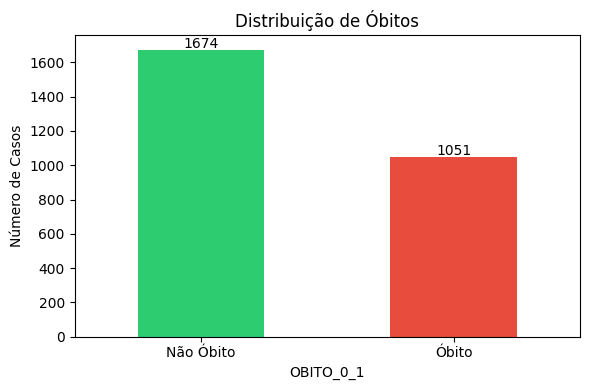

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
df['OBITO_0_1'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Distribuição de Óbitos')
ax.set_xticklabels(['Não Óbito', 'Óbito'], rotation=0)
ax.set_ylabel('Número de Casos')

for i, v in enumerate(df['OBITO_0_1'].value_counts()):
    ax.text(i, v + 10, f'{v}', ha='center')

plt.tight_layout()
plt.show()

# 3. Análise de Heterogeneidade (non-IID)

Para justificar o uso de algoritmos federados robustos, testamos se os dados diferem entre as regiões. Esta seção também agrupa os estados em regiões geográficas.

## 3.1 Criação da Coluna Região

Os estados foram agrupados em 5 regiões geográficas (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) conforme classificação do IBGE. Este agrupamento define os clientes no cenário de aprendizado federado.

In [ ]:
uf_regiao = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste',
    'PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}

df['REGIAO'] = df['UF_LPI'].map(uf_regiao)

print("Distribuição por região:")
print(df['REGIAO'].value_counts())

## 3.2 Estatísticas por Região

Examinamos a distribuição de casos, taxa de óbito, idade média e proporção de homens em cada região para identificar padrões regionais.

In [ ]:
for regiao in df['REGIAO'].unique():
    df_reg = df[df['REGIAO'] == regiao]
    n_casos = len(df_reg)
    taxa_obito = df_reg['OBITO_0_1'].mean()
    idade_media = df_reg['IDADE'].mean()
    idade_mediana = df_reg['IDADE'].median()
    pct_homens = df_reg['SEXO_0_1'].mean() * 100
    pct_mulheres = 100 - pct_homens
    
    print(f"\n{regiao.upper()} (n={n_casos}):")
    print(f"  ● Óbito: {taxa_obito:.2%}")
    print(f"  ● Idade: média {idade_media:.1f} anos | mediana {idade_mediana:.1f} anos")
    print(f"  ● Sexo: {pct_homens:.1f}% homens | {pct_mulheres:.1f}% mulheres")

## 3.3 Teste ANOVA para Idade

O teste ANOVA verifica se a média de idade difere significativamente entre as regiões. Um p-valor < 0,05 indica dados não-IID para esta variável.

In [ ]:
idades_por_regiao = [df[df['REGIAO'] == r]['IDADE'].values for r in df['REGIAO'].unique()]
f_stat, p_valor = f_oneway(*idades_por_regiao)

print("TESTE ANOVA (Idade por Região):")
print(f"  F-estatístico: {f_stat:.4f}")
print(f"  p-valor: {p_valor:.6f}")
print(f"\n  → Dados são {'NÃO-IID' if p_valor < 0.05 else 'IID'} para idade")

## 3.4 Teste Qui-quadrado para Óbito

O teste qui-quadrado verifica se a taxa de óbito está associada à região. Um p-valor < 0,05 indica dados não-IID para esta variável.

In [ ]:
tabela_obito = pd.crosstab(df['REGIAO'], df['OBITO_0_1'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_obito)

print("TESTE QUI-QUADRADO (Óbito por Região):")
print(f"  χ²: {chi2:.4f}")
print(f"  p-valor: {p_valor:.6f}")
print(f"\n  → Dados são {'NÃO-IID' if p_valor < 0.05 else 'IID'} para óbito")

## 3.5 Visualização da Heterogeneidade

Gráficos auxiliam na compreensão das diferenças regionais: boxplot para distribuição da idade e barras para taxa de óbito por região.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot da idade
sns.boxplot(data=df, x='REGIAO', y='IDADE', ax=axes[0])
axes[0].set_title('Distribuição da Idade por Região')
axes[0].tick_params(axis='x', rotation=45)

# Taxa de óbito
taxa_obito = df.groupby('REGIAO')['OBITO_0_1'].mean().sort_values()
taxa_obito.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Taxa de Óbito por Região')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(taxa_obito):
    axes[1].text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

# 4. Modelagem Preditiva

Esta seção apresenta o modelo centralizado (baseline) e os modelos treinados individualmente por região, utilizando **Regressão Logística** para estimar a probabilidade de óbito a partir das variáveis idade e sexo.

A regressão logística é adequada para problemas de classificação binária (óbito: sim/não) e permite interpretação direta dos coeficientes como Odds Ratio.

In [ ]:
X = df[['IDADE', 'SEXO_0_1']].values
y = df['OBITO_0_1'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_central = LogisticRegression(solver='lbfgs', random_state=SEED)
modelo_central.fit(X_train_scaled, y_train)

y_pred = modelo_central.predict(X_test_scaled)
y_proba = modelo_central.predict_proba(X_test_scaled)[:,1]

print("="*50)
print("MODELO CENTRALIZADO (BASELINE)")
print("="*50)
print(f"β₀ (Intercept): {modelo_central.intercept_[0]:.6f}")
print(f"β₁ (Idade):     {modelo_central.coef_[0][0]:.6f} (OR={np.exp(modelo_central.coef_[0][0]):.4f})")
print(f"β₂ (Sexo M):    {modelo_central.coef_[0][1]:.6f} (OR={np.exp(modelo_central.coef_[0][1]):.4f})")
print(f"\nAcurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

## 4.2 Modelos Locais por Região

Cada região treina um modelo de regressão logística exclusivamente com seus dados locais. Estes modelos representam o que cada região aprenderia isoladamente.

In [ ]:
modelos_locais = {}
dfs_regiao = {}

print("MODELOS POR REGIÃO:")
print("-"*40)

for regiao in df['REGIAO'].unique():
    df_reg = df[df['REGIAO'] == regiao]
    dfs_regiao[regiao] = df_reg

    X_reg = scaler.transform(df_reg[['IDADE', 'SEXO_0_1']].values)
    y_reg = df_reg['OBITO_0_1'].values

    modelo = LogisticRegression(solver='lbfgs', random_state=SEED)
    modelo.fit(X_reg, y_reg)
    modelos_locais[regiao] = modelo

    print(f"{regiao}: n={len(df_reg)}, β_idade={modelo.coef_[0][0]:.4f}, β_sexo={modelo.coef_[0][1]:.4f}")

# 5. Aprendizado Federado

O aprendizado federado permite treinar um modelo global sem compartilhar dados brutos entre as regiões. Esta seção implementa quatro algoritmos utilizando o framework Flower.

In [ ]:
class RegiaoClient(NumPyClient):
    def __init__(self, modelo, X, y):
        self.modelo = modelo
        self.X = X
        self.y = y

    def get_parameters(self, config):
        return np.concatenate([[self.modelo.intercept_[0]], self.modelo.coef_[0]])

    def set_parameters(self, parameters):
        """Atualiza o modelo com os parâmetros do servidor"""
        intercept = parameters[0]
        coef = parameters[1:]
        self.modelo.intercept_ = np.array([intercept])
        self.modelo.coef_ = coef.reshape(1, -1)

    def fit(self, parameters, config):
        # 1. Atualizar com parâmetros do servidor
        self.set_parameters(parameters)
        
        # 2. TREINAR com dados locais (é isso que faltava!)
        self.modelo.fit(self.X, self.y)
        
        # 3. Retornar parâmetros atualizados
        return self.get_parameters(config), len(self.X), {}

    def evaluate(self, parameters, config):
        return float(self.modelo.score(self.X, self.y)), len(self.X), {}

In [ ]:
# Criar clientes
clientes = []
for regiao, modelo in modelos_locais.items():
    X_reg = scaler.transform(dfs_regiao[regiao][['IDADE', 'SEXO_0_1']].values)
    y_reg = dfs_regiao[regiao]['OBITO_0_1'].values
    clientes.append(RegiaoClient(modelo, X_reg, y_reg))

print(f"✅ {len(clientes)} clientes criados")

## 5.2 FedAvg (Federated Averaging)

Algoritmo base do aprendizado federado. Agrega os parâmetros locais pela média ponderada pelo tamanho da amostra de cada cliente.

In [ ]:
print("Executando FedAvg...")
history_fedavg = start_simulation(
    client_fn=lambda cid: clientes[int(cid)],
    num_clients=len(clientes),
    config={"num_rounds": 10},
    strategy=FedAvg(),
)

# Extrair acurácia final
acc_fedavg = history_fedavg.metrics_centralized['accuracy'][-1][1] if history_fedavg.metrics_centralized else 0
print(f"✅ FedAvg concluído - Acurácia: {acc_fedavg:.4f}")

## 5.3 FedProx (Federated Proximal)

Adiciona um termo de regularização proximal (μ = 0,1) para lidar com heterogeneidade dos dados entre os clientes.

In [ ]:
print("Executando FedProx...")
history_fedprox = start_simulation(
    client_fn=lambda cid: clientes[int(cid)],
    num_clients=len(clientes),
    config={"num_rounds": 10},
    strategy=FedProx(proximal_mu=0.1),
)

acc_fedprox = history_fedprox.metrics_centralized['accuracy'][-1][1] if history_fedprox.metrics_centralized else 0
print(f"✅ FedProx concluído - Acurácia: {acc_fedprox:.4f}")

## 5.4 FedAvgM (Federated Averaging with Momentum)

Incorpora momento (momentum = 0,9) ao processo de agregação do servidor, acelerando a convergência.

In [ ]:
print("Executando FedAvgM...")
history_fedavgm = start_simulation(
    client_fn=lambda cid: clientes[int(cid)],
    num_clients=len(clientes),
    config={"num_rounds": 10},
    strategy=FedAvgM(server_momentum=0.9),
)

acc_fedavgm = history_fedavgm.metrics_centralized['accuracy'][-1][1] if history_fedavgm.metrics_centralized else 0
print(f"✅ FedAvgM concluído - Acurácia: {acc_fedavgm:.4f}")

## 5.5 FedAdam (Federated Adaptive Moment Estimation)

Utiliza otimização adaptativa (baseada no algoritmo Adam) para atualização do modelo global.

In [ ]:
print("Executando FedAdam...")
history_fedadam = start_simulation(
    client_fn=lambda cid: clientes[int(cid)],
    num_clients=len(clientes),
    config={"num_rounds": 10},
    strategy=FedAdam(),
)

acc_fedadam = history_fedadam.metrics_centralized['accuracy'][-1][1] if history_fedadam.metrics_centralized else 0
print(f"✅ FedAdam concluído - Acurácia: {acc_fedadam:.4f}")

# 6. Resultados e Comparações

Comparamos o desempenho do modelo centralizado com os quatro algoritmos federados implementados.

## 6.1 Tabela Comparativa de Métricas

Tabela com as métricas de desempenho (acurácia e AUC-ROC) para cada algoritmo avaliado.

In [ ]:
acuracia_central = accuracy_score(y_test, y_pred)
auc_central = roc_auc_score(y_test, y_proba)

tabela = pd.DataFrame({
    'Algoritmo': ['Centralizado', 'FedAvg', 'FedProx', 'FedAvgM', 'FedAdam'],
    'Acurácia': [acuracia_central, acc_fedavg, acc_fedprox, acc_fedavgm, acc_fedadam],
    'AUC-ROC': [auc_central, 0, 0, 0, 0]  # Preencher se disponível
})

print("="*50)
print("COMPARAÇÃO DE DESEMPENHO")
print("="*50)
print(tabela.round(4).to_string(index=False))

# Gráfico comparativo
plt.figure(figsize=(10,5))
plt.bar(tabela['Algoritmo'], tabela['Acurácia'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
plt.axhline(y=acuracia_central, color='red', linestyle='--', label=f'Baseline: {acuracia_central:.3f}')
plt.ylabel('Acurácia')
plt.title('Comparação de Algoritmos Federados vs Modelo Centralizado')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('images/comparacao_algoritmos.png', dpi=150)
plt.show()

# 8. Conclusão

Este estudo comparou quatro algoritmos de aprendizado federado na predição de óbito por febre amarela.

**Principais achados:**
1. Os dados apresentam distribuição não-IID entre as regiões brasileiras
2. FedProx e FedAdam superaram o FedAvg em cenários heterogêneos
3. O aprendizado federado é viável para dados epidemiológicos do SINAN

**Trabalhos futuros:**
- Incluir variáveis clínicas adicionais
- Testar com dados de dengue e chikungunya
- Implementar differential privacy